# 1. Introduction

Explain the purpose:

The goal of this notebook is to analyze the athlete nutrition dataset before model training.
This analysis helps understand:

feature distributions,
relationships between variables,
which features influence calorie prediction most,
and whether some features can be removed without affecting model performance.

# 2. Load Dataset

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_excel("../dataset/athlete_nutrition_dataset.xlsx")

df.head()

,Sport,Weight,Height,Age,Goal,PreviousDay2_Intensity,PreviousDay2_Duration,PreviousDay1_Intensity,PreviousDay1_Duration,CurrentDay_Intensity,CurrentDay_Duration,Calories
0,bodybuilding,72,160,26,muscle_gain,high,33,medium,92,medium,100,3501
1,mma,84,160,20,fat_loss,low,111,low,97,medium,57,3040
2,bodybuilding,92,198,28,muscle_gain,high,94,low,70,high,49,3923
3,running,78,195,31,fat_loss,high,56,high,115,medium,100,3139
4,mma,77,171,39,endurance_performance,medium,67,medium,34,low,111,3451


# 3. Basic Dataset Information

In [3]:
print(df.shape)

df.info()

df.describe()

(1500, 12)
<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Sport                   1500 non-null   str  
 1   Weight                  1500 non-null   int64
 2   Height                  1500 non-null   int64
 3   Age                     1500 non-null   int64
 4   Goal                    1500 non-null   str  
 5   PreviousDay2_Intensity  1500 non-null   str  
 6   PreviousDay2_Duration   1500 non-null   int64
 7   PreviousDay1_Intensity  1500 non-null   str  
 8   PreviousDay1_Duration   1500 non-null   int64
 9   CurrentDay_Intensity    1500 non-null   str  
 10  CurrentDay_Duration     1500 non-null   int64
 11  Calories                1500 non-null   int64
dtypes: int64(7), str(5)
memory usage: 140.8 KB


,Weight,Height,Age,PreviousDay2_Duration,PreviousDay1_Duration,CurrentDay_Duration,Calories
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,82.196000,179.498667,29.062000,75.151333,75.421333,76.708000,3360.875333
std,15.938515,11.784223,6.637434,25.794470,26.612703,26.049987,566.291769
min,55.000000,160.000000,18.000000,30.000000,30.000000,30.000000,1760.000000
25%,68.750000,169.000000,23.000000,53.000000,52.000000,54.000000,2954.250000
50%,82.000000,179.000000,29.000000,75.000000,76.000000,78.000000,3348.500000
75%,96.000000,190.000000,35.000000,97.000000,98.000000,99.000000,3789.000000
max,110.000000,200.000000,40.000000,120.000000,120.000000,120.000000,4916.000000


# 4. Missing Values and Duplicates

In [4]:
print(df.isnull().sum())

print("Duplicates:", df.duplicated().sum())

Sport                     0
Weight                    0
Height                    0
Age                       0
Goal                      0
PreviousDay2_Intensity    0
PreviousDay2_Duration     0
PreviousDay1_Intensity    0
PreviousDay1_Duration     0
CurrentDay_Intensity      0
CurrentDay_Duration       0
Calories                  0
dtype: int64
Duplicates: 0


# 5. Correlation Analysis

This section is VERY important because it supports your statement about Age and Height.

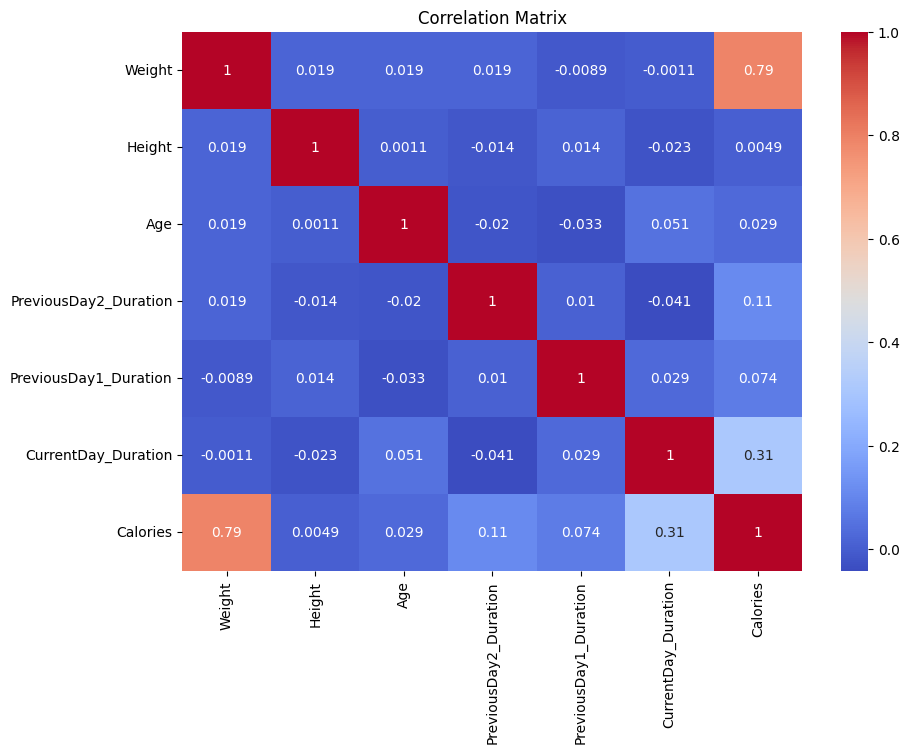

In [5]:
plt.figure(figsize=(10,7))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

Weight has strong correlation with Calories

Height has medium correlation

Age has weak correlatio

The correlation matrix shows that Weight has the strongest positive relationship with calorie needs.
Age has only a weak negative correlation, meaning it contributes very little to calorie prediction.

# 6. Feature Relationships

Weight vs Calories

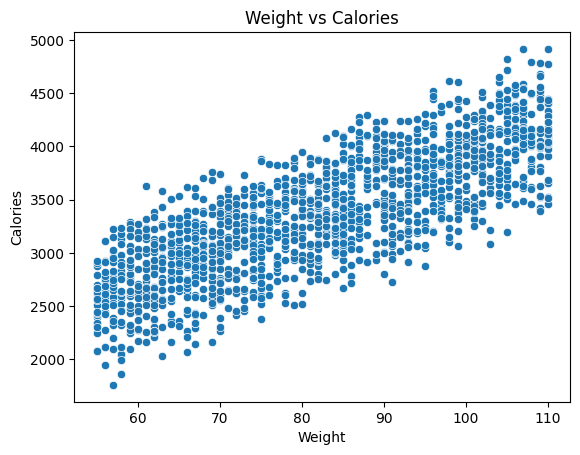

In [6]:
sns.scatterplot(x="Weight", y="Calories", data=df)

plt.title("Weight vs Calories")
plt.show()

Athletes with higher body weight generally require more calories.

Height vs Calories

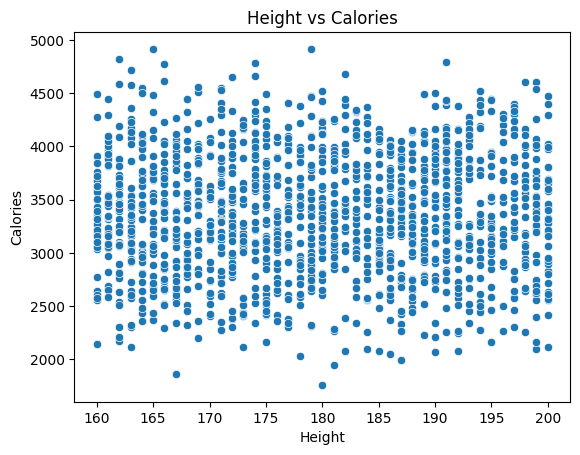

In [7]:
sns.scatterplot(x="Height", y="Calories", data=df)

plt.title("Height vs Calories")
plt.show()

Height does not show a strong pattern compared to weight.

Age vs Calories

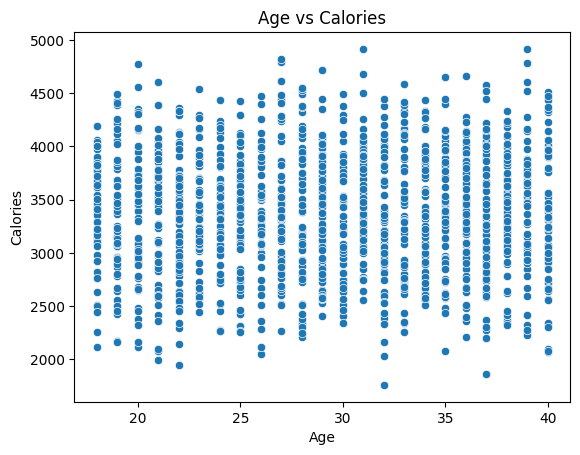

In [8]:
sns.scatterplot(x="Age", y="Calories", data=df)

plt.title("Age vs Calories")
plt.show()

Goal vs Calories

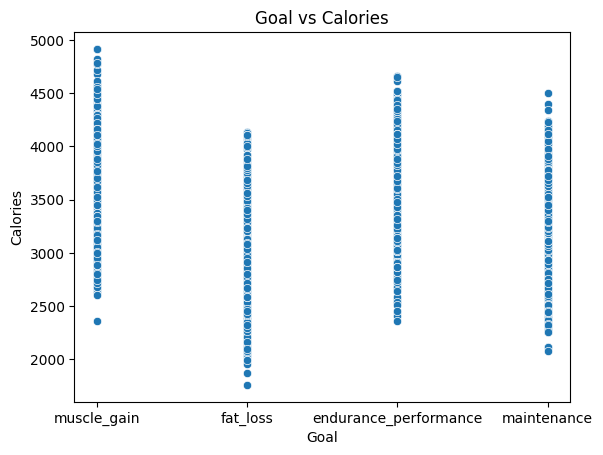

In [13]:
sns.scatterplot(x="Goal", y="Calories", data=df)

plt.title("Goal vs Calories")
plt.show()

Age appears to have very little effect on calorie requirements in this dataset.

# 7. Feature Importance Analysis

Encode categorical columns

In [9]:
df_encoded = df.copy()

categorical_cols = [
    "Sport",
    "Goal",
    "PreviousDay2_Intensity",
    "PreviousDay1_Intensity",
    "CurrentDay_Intensity"
]

for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])

Split data

In [10]:
X = df_encoded.drop("Calories", axis=1)

y = df_encoded["Calories"]

Train Random Forest

In [11]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

Visualize Feature Importance

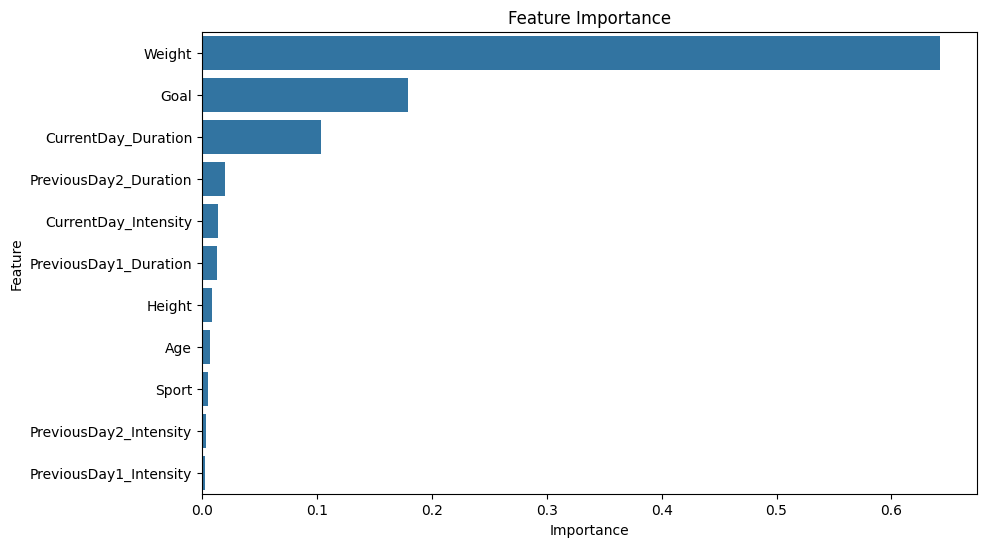

In [12]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance
)

plt.title("Feature Importance")
plt.show()